# 01 - EDA (Exploratory Data Analysis)
## Malicious URL Detection - Machine Learning Project
**Goal**: look at the subset carefully BEFORE building any model, to understand what it contains, whether it is reliable, and what it suggests. Nothing is trained here.

**Why** (repeat in the presentation):
1. Catch data-quality issues (missing values, duplicates) before they spoil feature engineering and training.
2. Verify that the stratified sampling in `make_subset.py` kept the original class proportions.
3. Build informed hypotheses about which features will be useful (see `src/features.py`).
4. Spot any mislabeled samples.
5. Have documented evidence (plots + observations) of the method, for the slides.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (7, 4)
sns.set_style("whitegrid")

## Loading the subset

In [2]:
from pathlib import Path

candidate_paths = [
    Path("../data/subset/malicious_urls_subset.csv"),
    Path("data/subset/malicious_urls_subset.csv"),
    Path("malicious_urls_subset.csv"),
]
subset_path = next((p for p in candidate_paths if p.exists()), None)
if subset_path is None:
    raise FileNotFoundError(f"Subset not found in: {[str(p) for p in candidate_paths]}")
print("Using file:", subset_path.resolve())
df = pd.read_csv(subset_path)

Using file: C:\Users\Matteo\Desktop\Cybersecurity\2_Sem\Machine Learning\Progetto\Git.py_project\data\subset\malicious_urls_subset.csv


## Block 1 - Structural check
Is the data clean? Any missing values or duplicate rows?

In [3]:
print("Rows, columns:", df.shape)
print("\nData type per column:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows (exact same url):", df.duplicated(subset=["url"]).sum())

Rows, columns: (15000, 2)

Data type per column:
url     str
type    str
dtype: object

Missing values per column:
url     0
type    0
dtype: int64

Duplicate rows (exact same url): 0


**Note**: `duplicated()` only finds identical URLs, not near-duplicates like `unica.it/page` vs `www.unica.it/page`. Worth reporting in the slides. Missing values are removed in the next cell (very few).

In [4]:
n_before = len(df)
df = df.dropna(subset=["url", "type"]).reset_index(drop=True)
n_after = len(df)
print(f"Rows removed due to missing values: {n_before - n_after} (from {n_before} to {n_after})")

Rows removed due to missing values: 0 (from 15000 to 15000)


## Block 2 - Class (target) distribution
Did stratified sampling keep the proportions? Expected: benign ~66%, defacement ~15%, phishing ~14%, malware ~5%.

type
benign        10016
defacement     2230
phishing       2201
malware         553
Name: count, dtype: int64

type
benign        66.8 %
defacement    14.9 %
phishing      14.7 %
malware        3.7 %
Name: proportion, dtype: str


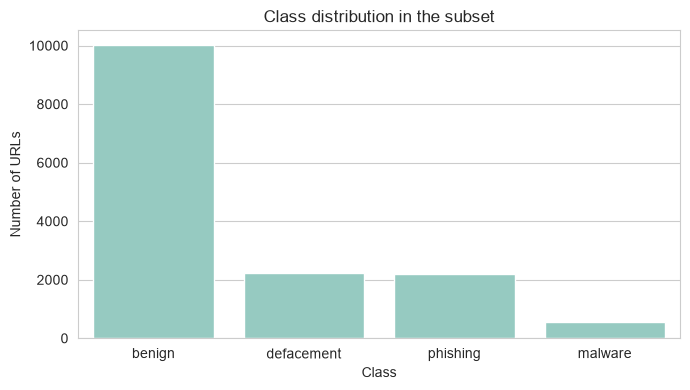

In [5]:
counts = df["type"].value_counts()
percentages = (df["type"].value_counts(normalize=True) * 100).round(1)
print(counts)
print()
print(percentages.astype(str) + " %")

plt.figure()
sns.countplot(data=df, x="type", order=counts.index)
plt.title("Class distribution in the subset")
plt.xlabel("Class"); plt.ylabel("Number of URLs")
plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=150)
plt.show()

## Block 3 - Qualitative look at real examples
Do the labels make sense? Read a few URLs per class.

In [6]:
for cls in df["type"].unique():
    print(f"\n--- {cls} ({(df['type'] == cls).sum()} examples) ---")
    for u in df[df["type"] == cls]["url"].sample(5, random_state=42).tolist():
        print(" ", u)


--- phishing (2201 examples) ---
  www.atlas-games.com/onceuponatime/
  www.webring.com/hub?ring=game_controls
  www.equi4.com/tclkit/
  http://quintascastaldi.com.br/name/assume
  www.dmm.cz/en/dmm_window_dll.htm

--- benign (10016 examples) ---
  blackamericaweb.com/?q=articles/news/the_black_diaspora_news/28337
  sidneyperkowitz.net/
  parl.gc.ca/HousePublications/Publication.aspx?DocId=1172416&Language=E&Mode=1&Parl=37&Ses=2
  webtonagent.com/en/index.php
  uk.tourisme93.com/document.php?pagendx=10011

--- malware (553 examples) ---
  http://zeroterwwgfbot.hoesbigmadzero.tk/bins/911.mips
  https://mitsui-jyuku.mixh.jp/uploads/9564d4fe8115bf6b56a9f2357e2c9e699c5.exe
  http://haishundl.com/a/qinpengqipaiguanfangxiazai/20131001/130.html
  http://37.49.226.182/bins/sora.x86
  http://194.36.188.170/sparc

--- defacement (2230 examples) ---
  http://neues-atelierhaus-panzerhalle.de/kuenstler/silvia-klara-breitwieser/132-silvia-klara-breitwieser-arbeiten.html
  http://www.baileybct.com/c

**Note for the slides**: write 2-3 qualitative observations (e.g. phishing imitates known brands; malware points to executable files). These justify the features in `features.py`.

## Block 4 - First numerical look: URL length per class

            mean  min   max
type                       
benign      57.7    8  1025
defacement  84.6   23   299
malware     46.6   10   231
phishing    45.0    8   461


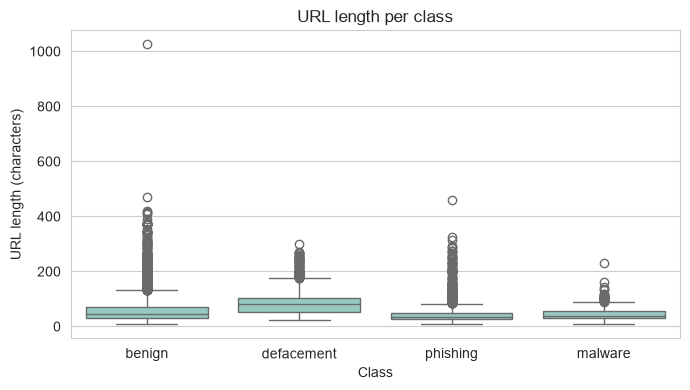

In [7]:
df["url_length"] = df["url"].str.len()
print(df.groupby("type")["url_length"].agg(["mean", "min", "max"]).round(1))

plt.figure()
sns.boxplot(data=df, x="type", y="url_length", order=counts.index)
plt.title("URL length per class")
plt.xlabel("Class"); plt.ylabel("URL length (characters)")
plt.tight_layout()
plt.savefig("../figures/url_length_per_class.png", dpi=150)
plt.show()

## Conclusions
- The subset has 15,000 rows and 2 columns (url, type), both textual. There are no missing values (url: 0, type: 0) and no exact-duplicate URLs (duplicates were removed in make_subset.py before sampling): the data is structurally clean and ready for feature engineering.
- The class proportions match the original dataset: benign 66.8%, defacement 14.9%, phishing 14.7%, malware 3.7%. This confirms that the stratified sampling worked correctly and kept the (strong) class imbalance, which we must keep in mind when evaluating the models.
- Qualitative observations on the 4 classes: benign URLs mostly point to normal domains and paths; phishing URLs often imitate known brands and use security-related words (login, verify, account); malware URLs frequently use raw IP addresses or numeric/executable paths; defacement URLs tend to be longer, with deeper paths.
- URL length already shows a measurable pattern: defacement URLs are clearly the longest on average (mean 84.6 chars), followed by benign (57.7), while malware (46.6) and phishing (45.0) are the shortest. However the distributions overlap heavily and there are extreme outliers (one benign URL of 1025 chars), so URL length alone is only a weak-to-moderate signal - useful mainly to flag defacement. The richer features of the next step will be needed.

**Next step**: 02_feature_engineering.ipynb.